# **Capstone Project (Data Science): BurnAway**

**ID Tim:** CC26-PSU237

**Anggota Tim:**
- Muhammad Fikri Rouzan Ash Shidik (Data Scientist - CDCC224D6Y0758)
- Hafidz Surya Afifi (Data Scientist - CDCC224D6Y2679)
- Aulia Salsabila (Full-Stack Web Developer - CFCC288D6X2031)
- Muhammad Radhya Firaz Maynard (Full-Stack Web Developer - CFCC224D6Y2852)
- Salwa Syaharani Putri (AI Engineer - CACC224D6X0556)
- Danuardi Saputro (AI Engineer - CACC224D6Y1221)

## **Informasi Dataset**

Dataset ini menyajikan gambaran mendalam mengenai faktor fisik dan perilaku kerja yang memengaruhi tingkat burnout developer. Dataset ini mencakup 7.000 sampel data aktivitas harian, yang mencakup berbagai atribut beban kerja, pola istirahat, serta metrik produktivitas.

### **Sumber Dataset**

**Kaggle:** https://www.kaggle.com/datasets/asifxzaman/developer-burnout-prediction-dataset7000-samples

### **Fitur Utama**

- **`age`**: Usia developer dalam satuan tahun.
- **`experience_years`**: Total durasi pengalaman kerja profesional dalam hitungan tahun.
- **`daily_work_hours`**: Durasi waktu yang digunakan untuk bekerja setiap hari.
- **`sleep_hours`**: Durasi waktu istirahat tidur dalam satu hari.
- **`caffeine_intake`**: Jumlah konsumsi kafein harian dalam hitungan cangkir.
- **`bugs_per_day`**: Jumlah kesalahan pada kode yang dihasilkan setiap hari.
- **`commits_per_day`**: Jumlah riwayat pengiriman kode ke repositori dalam sehari.
- **`meetings_per_day`**: Jumlah pertemuan yang harus dihadiri developer setiap hari.
- **`screen_time`**: Total durasi waktu menatap layar perangkat digital harian.
- **`exercise_hours`**: Durasi waktu untuk melakukan aktivitas fisik harian.
- **`stress_level`**: Skor tingkat stres dalam rentang 0 sampai 100.
- **`burnout_level`**: Variabel target yang menunjukkan tingkat burnout developer.

## **Latar Belakang Masalah**

Burnout telah diakui oleh World Health Organization (WHO) dalam ICD-11 sebagai occupational phenomenon yang muncul akibat stres kerja kronis yang tidak berhasil dikelola. Pada industri pengembangan perangkat lunak, burnout menjadi masalah serius yang berdampak pada mayoritas developer. Studi Haystack Analytics pada tahun 2021 menunjukkan bahwa 83% developer perangkat lunak mengalami burnout akibat tingginya beban kerja, proses kerja yang tidak efisien, dan target yang tidak jelas.

Kondisi tersebut dapat menurunkan produktivitas, kualitas perangkat lunak, serta memengaruhi kesejahteraan psikologis developer. Oleh karena itu, solusi utama yang akan dikembangkan dalam proyek ini adalah melakukan analisis data untuk mengidentifikasi faktor-faktor utama pendorong burnout, guna menghasilkan rekomendasi kebijakan kerja berbasis data yang dapat membantu menekan resiko burnout dan menjaga kesejahteraan developer.

## **Menentukan Pertanyaan Bisnis**

- Pertanyaan 1: Bagaimana pengaruh faktor jam kerja, waktu tidur, dan intensitas penggunaan layar terhadap tingkat burnout pada developer?
- Pertanyaan 2: Bagaimana pengaruh keseimbangan antara jam kerja dan waktu tidur terhadap tingkat burnout pada developer?
- Pertanyaan 3: Bagaimana pengaruh tingkat stres terhadap tingkat burnout pada developer?
- Pertanyaan 4: Apakah intensitas paparan layar yang tinggi relatif terhadap jam kerja secara signifikan meningkatkan resiko burnout yang lebih berat?
- Pertanyaan 5: Bagaimana hubungan antara efisiensi kerja dengan tingkat burnout developer? Apakah developer dengan efisiensi rendah cenderung mengalami burnout lebih tinggi?

## **Import Library**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.proportion import proportions_ztest

## **Data Wrangling**

### **Gathering Data**

In [2]:
df = pd.read_csv("https://drive.google.com/uc?export=download&id=1-ywUrU0CaV7rK67WY-PjacULIc3_Yb-5")
df

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96,Medium
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22,High
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,Medium
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98,Medium
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,27.90,Low
...,...,...,...,...,...,...,...,...,...,...,...,...
6995,25.0,14.0,6.53,7.43,5.0,1.0,7.0,5.0,7.55,1.67,20.10,Low
6996,30.0,19.0,10.15,5.60,3.0,4.0,9.0,0.0,12.11,0.96,41.71,Medium
6997,44.0,8.0,8.56,6.80,5.0,18.0,3.0,4.0,11.62,1.04,80.15,High
6998,25.0,2.0,4.39,5.40,6.0,6.0,4.0,5.0,8.24,0.82,41.44,Medium


**Insight:**
- Dataset developer burnout berhasil ditampilkan dalam 5 baris pertama dan 5 baris terakhir.
- Dataset ini masih memiliki value NaN dibeberapa kolom dan perlu ditangani pada tahap cleaning berikutnya.
- Dataset ini memiliki 7.000 baris dan 12 kolom.

### **Assessing Data**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               6860 non-null   float64
 1   experience_years  6860 non-null   float64
 2   daily_work_hours  6860 non-null   float64
 3   sleep_hours       6860 non-null   float64
 4   caffeine_intake   6860 non-null   float64
 5   bugs_per_day      6860 non-null   float64
 6   commits_per_day   6860 non-null   float64
 7   meetings_per_day  6860 non-null   float64
 8   screen_time       6860 non-null   float64
 9   exercise_hours    6860 non-null   float64
 10  stress_level      6860 non-null   float64
 11  burnout_level     6860 non-null   object 
dtypes: float64(11), object(1)
memory usage: 656.4+ KB


**Insight:**
- Dataset ini memiliki 7.000 baris, namun pada bagian Non-Null Count, terlihat semua kolom hanya memiliki 6.860 baris data yang terisi. Hal ini menandakan adanya data yang hilang dan perlu ditangani pada tahap cleaning berikutnya.
- Hampir semua kolom bertipe float64, kecuali kolom burnout_level yang bertipe object (string).

In [4]:
df.isna().sum()

,0
age,140
experience_years,140
daily_work_hours,140
sleep_hours,140
caffeine_intake,140
bugs_per_day,140
commits_per_day,140
meetings_per_day,140
screen_time,140
exercise_hours,140


**Insight:**
- Terlihat kalau setiap kolom memiliki 140 nilai yang kosong. Nilai yang kosong ini akan diisi menggunakan metode imputasi pada tahap cleaning berikutnya.

In [5]:
df.duplicated().sum()

np.int64(0)

**Insight:**
- Tidak ditemukan adanya data yang terduplikasi pada dataset ini.

In [6]:
df.describe()

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level
count,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000
mean,32.129446,9.581050,9.000277,6.485638,3.540671,9.482653,14.458455,4.545044,11.974773,1.007611,53.652825
std,7.230254,5.760972,2.863944,1.445008,2.283445,5.751664,8.669846,2.856766,3.091204,0.576708,23.446656
min,20.000000,0.000000,4.000000,4.000000,0.000000,0.000000,0.000000,0.000000,5.210000,0.000000,0.000000
25%,26.000000,5.000000,6.560000,5.220000,2.000000,5.000000,7.000000,2.000000,9.460000,0.510000,36.587500
50%,32.000000,10.000000,8.990000,6.460000,4.000000,9.000000,14.000000,5.000000,12.020000,1.020000,53.795000
75%,38.000000,15.000000,11.422500,7.740000,6.000000,14.000000,22.000000,7.000000,14.422500,1.510000,70.800000
max,44.000000,19.000000,14.000000,9.000000,7.000000,19.000000,29.000000,9.000000,18.930000,2.000000,100.000000


**Insight:**
- Rata-rata developer dalam dataset ini berusia sekitar 32 tahun, dengan rentang usia paling muda 20 tahun dan paling tua 44 tahun.
- Rata-rata developer bekerja selama 9 jam/hari, namun rata-rata waktu tidurnya hanya 6,4 jam/hari.
- Rata-rata developer mengkonsumsi kafein 3,5 unit/hari, dengan maksimal mencapai 7 unit/hari.
- Rata-rata developer memiliki level stres yang mencapai 53,6 dengan skala 0 hingga 100.

### **Cleaning Data**

In [7]:
# Membuat salinan dataframe
df_clean = df.copy()

# Imputasi kolom numerik dengan nilai median
numerical_cols = df_clean.select_dtypes(include=['float64']).columns
medians = df_clean[numerical_cols].median()
print("=== Nilai Median Untuk Imputasi Kolom Numerik ===")
print(medians)
print("\n")
df_clean[numerical_cols] = df_clean[numerical_cols].fillna(medians)

# Imputasi kolom kategorikal dengan Nilai Modus
categorical_col = df_clean['burnout_level'].mode()[0]
df_clean['burnout_level'] = df_clean['burnout_level'].fillna(categorical_col)
print(f"Nilai Modus Untuk Imputasi Kolom burnout_level: {categorical_col}")

# Verifikasi
print("\n=== Cek DataFrame Setelah Imputasi ===")
df_clean.info()

=== Nilai Median Untuk Imputasi Kolom Numerik ===
age                 32.000
experience_years    10.000
daily_work_hours     8.990
sleep_hours          6.460
caffeine_intake      4.000
bugs_per_day         9.000
commits_per_day     14.000
meetings_per_day     5.000
screen_time         12.020
exercise_hours       1.020
stress_level        53.795
dtype: float64


Nilai Modus Untuk Imputasi Kolom burnout_level: Medium

=== Cek DataFrame Setelah Imputasi ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               7000 non-null   float64
 1   experience_years  7000 non-null   float64
 2   daily_work_hours  7000 non-null   float64
 3   sleep_hours       7000 non-null   float64
 4   caffeine_intake   7000 non-null   float64
 5   bugs_per_day      7000 non-null   float64
 6   commits_per_day   7000 non-null   float64
 7   meetin

**Insight:**
- Setiap kolom numerik berhasil diisi dengan nilai tengah (median).
- Kolom burnout_level diisi dengan nilai Medium (modus). Hal ini menunjukkan bahwa secara mayoritas, developer dalam dataset ini berada pada tingkat burnout menengah.
- Dataset kini memiliki 7.000 baris pada bagian Non-Null Count. Hal ini menunjukkan bahwa tidak ada lagi data yang hilang pada setiap kolom.

## **Feature Engineering**

In [8]:
# Fitur rasio beban kerja dan istirahat
df_clean['work_sleep_ratio'] = df_clean['daily_work_hours'] / (df_clean['sleep_hours'] + 0.1)

# Fitur intensitas paparan layar
df_clean['screen_time_intensity'] = df_clean['screen_time'] / (df_clean['daily_work_hours'] + 0.1)

# Fitur efisiensi produksi
df_clean['commit_bug_ratio'] = df_clean['commits_per_day'] / (df_clean['bugs_per_day'] + 0.1)

# Fitur kategori keseimbangan beban kerja dan istirahat
df_clean['work_category'] = pd.cut(
    df_clean['work_sleep_ratio'],
    bins=[0, 1, 2, 3, 10],
    labels=['Seimbang', 'Cukup Tinggi', 'Tinggi', 'Sangat Tinggi']
)

# Verifikasi
print("=== Cek DataFrame Setelah Feature Engineering ===")
df_clean.info()

# Menampilkan 5 baris pertama fitur baru
print("\n=== Sampel Fitur Baru Terhadap Level Burnout ===")
df_clean[['work_sleep_ratio', 'screen_time_intensity', 'commit_bug_ratio', 'work_category', 'burnout_level']].head()

=== Cek DataFrame Setelah Feature Engineering ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   age                    7000 non-null   float64 
 1   experience_years       7000 non-null   float64 
 2   daily_work_hours       7000 non-null   float64 
 3   sleep_hours            7000 non-null   float64 
 4   caffeine_intake        7000 non-null   float64 
 5   bugs_per_day           7000 non-null   float64 
 6   commits_per_day        7000 non-null   float64 
 7   meetings_per_day       7000 non-null   float64 
 8   screen_time            7000 non-null   float64 
 9   exercise_hours         7000 non-null   float64 
 10  stress_level           7000 non-null   float64 
 11  burnout_level          7000 non-null   object  
 12  work_sleep_ratio       7000 non-null   float64 
 13  screen_time_intensity  7000 non-null   floa

,work_sleep_ratio,screen_time_intensity,commit_bug_ratio,work_category,burnout_level
0,2.270330,1.444871,0.360360,Tinggi,Medium
1,1.468484,1.519495,0.728477,Cukup Tinggi,High
2,2.176755,1.229923,8.571429,Tinggi,Medium
3,1.042618,1.602878,1.721854,Cukup Tinggi,Medium
4,0.718644,1.854839,1.868132,Seimbang,Low


**Insight:**
- Fitur baru work_sleep_ratio berhasil dibuat. Fitur ini mengukur keseimbangan antara waktu kerja dan waktu tidur untuk mendeteksi potensi kelelahan fisik secara kuantitatif.
- Fitur baru screen_time_intensity berhasil dibuat. Fitur ini memantau durasi penggunaan perangkat digital selama jam kerja untuk melihat beban mata dan mental bagi developer.
- Fitur baru commit_bug_ratio berhasil dibuat. Fitur ini menilai perbandingan hasil kerja terhadap kesalahan yang muncul sebagai indikator performa kerja harian.
- Fitur baru work_category berhasil dibuat. Fitur ini mengelompokkan rasio kerja dan tidur ke dalam kategori kualitatif untuk mempermudah interpretasi tingkat resiko beban kerja dan istirahat.
- 4 Fitur baru tersebut berhasil ditampilkan dalam 5 baris pertama.

## **Label Encoding**

In [9]:
# Mapping kolom level burnout
df_clean['burnout_level'] = df_clean['burnout_level'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})

# Mapping kolom kategori keseimbangan beban kerja dan istirahat
df_clean['work_category'] = df_clean['work_category'].map({
    'Seimbang': 0,
    'Cukup Tinggi': 1,
    'Tinggi': 2,
    'Sangat Tinggi': 3
}).astype(int)

df_clean.head()

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level,work_sleep_ratio,screen_time_intensity,commit_bug_ratio,work_category
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96,1,2.270330,1.444871,0.360360,2
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22,2,1.468484,1.519495,0.728477,1
2,34.0,13.0,8.99,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,1,2.176755,1.229923,8.571429,2
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98,1,1.042618,1.602878,1.721854,1
4,27.0,7.0,4.24,5.80,4.0,9.0,17.0,7.0,8.05,0.36,27.90,0,0.718644,1.854839,1.868132,0


**Insight:**
- Kolom burnout_level dan work_category berhasil dikonversi menjadi bentuk numerik.
- Pada kolom burnout_level, nilai 0 merepresentasikan tingkat burnout rendah (Low), nilai 1 merepresentasikan tingkat burnout sedang (Medium), dan nilai 2 merepresentasikan tingkat burnout tinggi (High).
- Pada kolom work_category, nilai 0 merepresentasikan kategori Seimbang, nilai 1 merepresentasikan kategori Cukup Tinggi, nilai 2 merepresentasikan kategori Tinggi, dan nilai 3 merepresentasikan kategori Sangat Tinggi.
- Proses encoding dilakukan secara manual untuk menjaga urutan ordinal dari tingkat burnout.

## **Exploratory Data Analysis (EDA)**

In [10]:
# EDA untuk pertanyaan 1
print("=== Faktor Fisik Terhadap Tingkat Burnout ===")
display(df_clean.groupby(by="burnout_level").agg({
    "daily_work_hours": ["mean", "max", "min"],
    "sleep_hours": ["mean", "max", "min"],
    "screen_time": ["mean", "max", "min"]
}))

# EDA untuk pertanyaan 2
print("\n\n=== Rasio Beban Kerja dan Istirahat Terhadap Tingkat Burnout ===")
display(df_clean.groupby(by="work_category", observed=False).agg({
    "burnout_level": ["mean", "max", "min"]
}))

# EDA untuk pertanyaan 3
print("\n\n=== Tingkat Stres Terhadap Tingkat Burnout ===")
display(df_clean.groupby(by="burnout_level").agg({
    "stress_level": ["mean", "max", "min"]
}))

# EDA untuk pertanyaan 4
print("\n\n=== Intensitas Paparan Layar Terhadap Tingkat Burnout ===")
display(df_clean.groupby(by="burnout_level").agg({
    "screen_time_intensity": ["mean", "median", "std"]
}))

# EDA untuk pertanyaan 5
print("\n\n=== Efisiensi Produksi Dengan Tingkat Burnout ===")
display(df_clean.groupby(by="burnout_level").agg({
    "commit_bug_ratio": ["mean", "median", "std"]
}))

=== Faktor Fisik Terhadap Tingkat Burnout ===


daily_work_hours              sleep_hours           screen_time  \
                          mean    max   min        mean  max  min        mean   
burnout_level                                                                   
0                     6.741707  13.97  4.00    6.972128  9.0  4.0    9.751030   
1                     8.947909  14.00  4.00    6.463812  9.0  4.0   11.920246   
2                    11.125022  14.00  4.08    6.093131  9.0  4.0   14.077138   

                            
                 max   min  
burnout_level               
0              17.86  5.21  
1              18.74  5.24  
2              18.93  5.37



=== Rasio Beban Kerja dan Istirahat Terhadap Tingkat Burnout ===


burnout_level        
                       mean max min
work_category                      
0                  0.509626   2   0
1                  1.099159   2   0
2                  1.538256   2   0
3                  1.742424   2   1



=== Tingkat Stres Terhadap Tingkat Burnout ===


stress_level                 
                      mean      max     min
burnout_level                              
0                22.769209   53.795   0.000
1                52.927741  100.000   4.710
2                82.747065  100.000  53.795



=== Intensitas Paparan Layar Terhadap Tingkat Burnout ===


screen_time_intensity                    
                               mean    median       std
burnout_level                                          
0                          1.463400  1.423290  0.248408
1                          1.350300  1.316993  0.199962
2                          1.269026  1.253314  0.148146



=== Efisiensi Produksi Dengan Tingkat Burnout ===


commit_bug_ratio                     
                          mean    median        std
burnout_level                                      
0                    18.465555  2.727273  50.629051
1                     8.281508  1.523179  32.753459
2                     2.908736  1.074380  16.510830

**Insight:**
- Developer pada burnout level 2 (High) memiliki rata-rata jam kerja (11,12 jam) dan screen time (14,07 jam) tertinggi, serta durasi tidur paling rendah (6,09 jam) dibandingkan level lainnya.
- Burnout level 1 (Medium) secara konsisten berada di titik tengah untuk semua parameter, menunjukkan adanya korelasi linear antara beban kerja dengan tingkat burnout.
- Peningkatan rasio antara beban kerja dan waktu istirahat berbanding lurus dengan kenaikan rata-rata tingkat burnout pada setiap kategori.
- Rasio beban kerja dan istirahat pada kategori 3 (Sangat Tinggi) mencatatkan rata-rata burnout tertinggi sebesar 1,74 sementara kategori 0 (Seimbang) memiliki angka terendah di level 0,5.
- Rata-rata level stres meningkat drastis dari angka 22,76 pada burnout level 0 (Low) hingga mencapai puncaknya di angka 82,74 pada burnout level 2 (High).
- Rata-rata intensitas paparan layar menurun secara bertahap seiring kenaikan tingkat burnout, dengan angka terendah sebesar 1,26 pada level 2 (High) yang menunjukkan jam kerja yang semakin panjang mulai mendominasi total durasi penggunaan perangkat secara keseluruhan.
- Efisiensi kerja mengalami penurunan drastis dari rata-rata 18,46 pada burnout level 0 (Low) menjadi hanya 2,9 pada burnout level 2 (High), membuktikan bahwa tingkat burnout yang tinggi berdampak buruk pada kualitas dan produktivitas hasil kerja developer.

## **Visualization & Explanatory Analysis**

### **Pertanyaan Bisnis 1: Bagaimana pengaruh faktor jam kerja, waktu tidur, dan intensitas penggunaan layar terhadap tingkat burnout pada developer?**

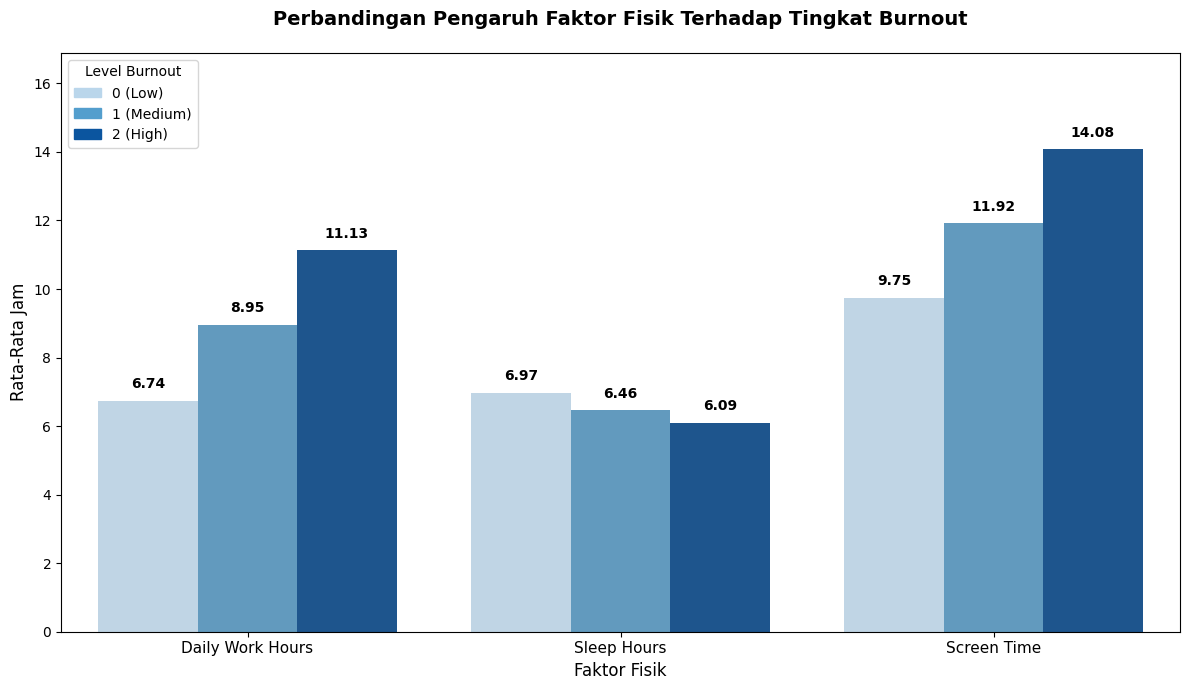

In [11]:
# Agregasi data untuk Menghitung rata-rata faktor per level burnout
eda_plot = df_clean.groupby("burnout_level")[[
    "daily_work_hours",
    "sleep_hours",
    "screen_time"
]].mean().reset_index()

# Transformasi data ke format long
eda_melted = eda_plot.melt(
    id_vars="burnout_level",
    var_name="Faktor",
    value_name="Rata-rata"
)

# Skema warna
palette_base = sns.color_palette("Blues", 6)
colors = {0: palette_base[1], 1: palette_base[3], 2: palette_base[5]}

# Visualisasi
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=eda_melted,
    x="Faktor",
    y="Rata-rata",
    hue="burnout_level",
    palette=colors,
    errorbar=None
)
max_val = eda_melted["Rata-rata"].max()
plt.ylim(0, max_val * 1.2)
plt.title("Perbandingan Pengaruh Faktor Fisik Terhadap Tingkat Burnout", fontsize=14, fontweight='bold', pad=20)
plt.ylabel("Rata-Rata Jam", fontsize=12)
plt.xlabel("Faktor Fisik", fontsize=12)
plt.xticks(ticks=[0, 1, 2], labels=["Daily Work Hours", "Sleep Hours", "Screen Time"], fontsize=11)

# Legend custom
low_patch = mpatches.Patch(color=colors[0], label='0 (Low)')
med_patch = mpatches.Patch(color=colors[1], label='1 (Medium)')
high_patch = mpatches.Patch(color=colors[2], label='2 (High)')
plt.legend(handles=[low_patch, med_patch, high_patch], title="Level Burnout", loc='upper left')

# Label angka di atas setiap bar
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(format(p.get_height(), '.2f'),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 12),
                    textcoords = 'offset points',
                    fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:**
- Developer dengan burnout High memiliki rata-rata jam kerja (11,13 jam) dan waktu layar (14,08 jam) paling tinggi, serta waktu tidur (6,09 jam) paling rendah.
- Developer dengan burnout Low menunjukkan kondisi sebaliknya yaitu jam kerja lebih rendah (6,74 jam), waktu layar lebih kecil (9,75 jam), dan waktu tidur lebih cukup (6,97 jam).
- Developer dengan burnout Medium berada di antara keduanya, menunjukkan pola yang konsisten.
- Pola ini mengindikasikan bahwa peningkatan jam kerja dan waktu layar, serta penurunan waktu tidur, berkontribusi signifikan terhadap kenaikan tingkat burnout.

### **Pertanyaan Bisnis 2: Bagaimana pengaruh keseimbangan antara jam kerja dan waktu tidur terhadap tingkat burnout pada developer?**

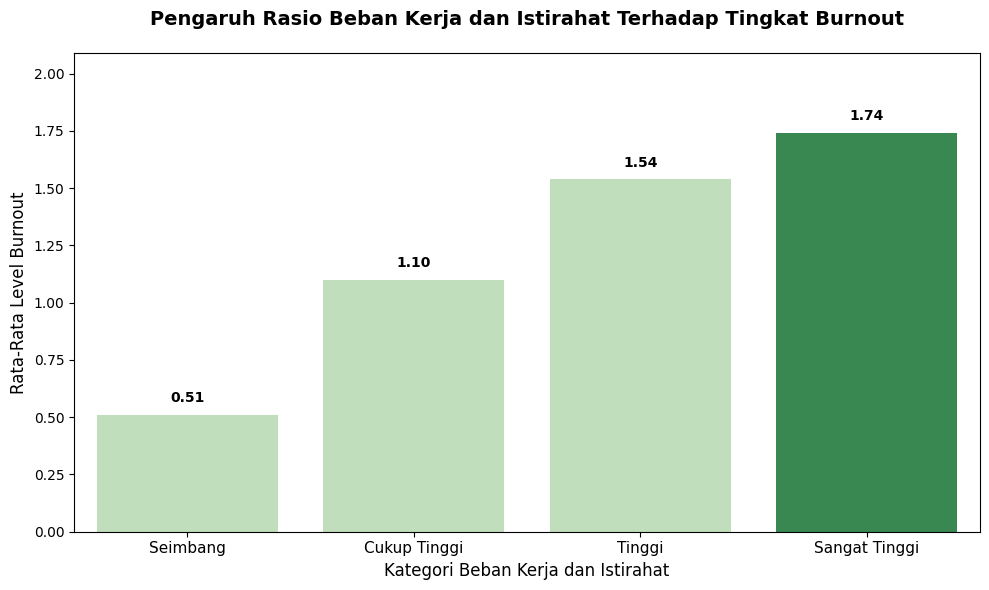

In [12]:
# Agregasi data untuk mencari nilai tertinggi
avg_work_burnout = df_clean.groupby('work_category', observed=False)['burnout_level'].mean()
max_val = avg_work_burnout.max()

# Skema warna
palette_base = sns.color_palette("Greens", 6)
base_color = palette_base[1]
highlight_color = palette_base[4]

# List warna berdasarkan kondisi
colors = [highlight_color if i == avg_work_burnout.idxmax() else base_color for i in avg_work_burnout.index]

# Visualisasi
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=avg_work_burnout.index,
    y=avg_work_burnout.values,
    palette=colors,
    hue=avg_work_burnout.index,
    legend=False,
    errorbar=None
)
ax.set_xticks(range(len(avg_work_burnout.index)))
ax.set_xticklabels(['Seimbang', 'Cukup Tinggi', 'Tinggi', 'Sangat Tinggi'], fontsize=11)
plt.ylim(0, max_val * 1.2)
plt.title('Pengaruh Rasio Beban Kerja dan Istirahat Terhadap Tingkat Burnout', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Kategori Beban Kerja dan Istirahat', fontsize=12)
plt.ylabel('Rata-Rata Level Burnout', fontsize=12)

# Label angka di atas bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 12),
                textcoords = 'offset points',
                fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:**
- Terdapat kenaikan yang konsisten pada rata-rata burnout seiring meningkatnya kategori beban kerja dan istirahat (dari 0,51 ke 1,74).
- Kategori Sangat Tinggi memiliki burnout tertinggi, menunjukkan kondisi kerja jauh lebih dominan dibanding waktu istirahat.
- Kategori Seimbang memiliki burnout paling rendah, menandakan keseimbangan kerja dan tidur mampu menekan resiko burnout.
- Perbedaan antar kategori terlihat cukup signifikan, sehingga rasio kerja terhadap istirahat menjadi indikator kuat dalam memprediksi tingkat burnout developer.

### **Pertanyaan Bisnis 3: Bagaimana pengaruh tingkat stres terhadap tingkat burnout pada developer?**

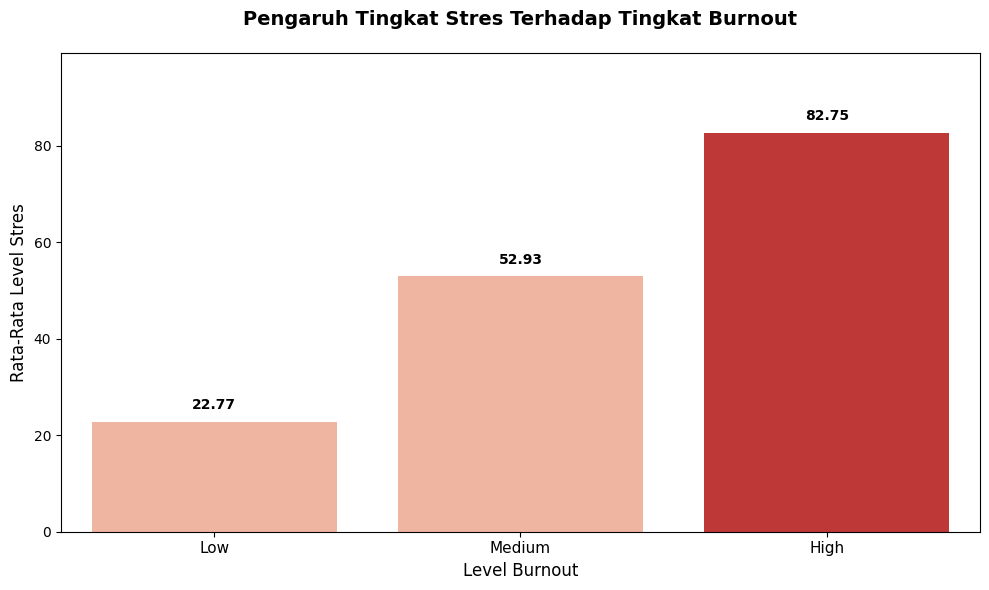

In [13]:
# Agregasi data untuk mencari nilai tertinggi
avg_stress = df_clean.groupby('burnout_level', observed=False)['stress_level'].mean()
max_val = avg_stress.max()

# Skema warna
palette_base = sns.color_palette("Reds", 6)
base_color = palette_base[1]
highlight_color = palette_base[4]

# List warna berdasarkan kondisi
colors = [highlight_color if i == avg_stress.idxmax() else base_color for i in avg_stress.index]

# Visualisasi
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=avg_stress.index,
    y=avg_stress.values,
    palette=colors,
    hue=avg_stress.index,
    legend=False,
    errorbar=None
)
ax.set_xticks(range(len(avg_stress.index)))
ax.set_xticklabels(['Low', 'Medium', 'High'], fontsize=11)
plt.ylim(0, max_val * 1.2)
plt.title('Pengaruh Tingkat Stres Terhadap Tingkat Burnout', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Level Burnout', fontsize=12)
plt.ylabel('Rata-Rata Level Stres', fontsize=12)

# Label angka di atas bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 12),
                textcoords = 'offset points',
                fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:**
- Rata-rata tingkat stres meningkat tajam dari Low (22,77) ke Medium (52,93) lalu ke High (82,75).
- Developer dengan burnout High memiliki tingkat stres yang jauh lebih tinggi dibanding kategori lainnya.
- Kenaikan ini menunjukkan pola yang sangat konsisten dan signifikan antar tingkat burnout.
- Hal ini mengindikasikan bahwa  tingkat stres merupakan faktor yang sangat kuat dan dominan dalam memengaruhi tingkat burnout developer.

### **Pertanyaan Bisnis 4: Apakah intensitas paparan layar yang tinggi relatif terhadap jam kerja secara signifikan meningkatkan resiko burnout yang lebih berat?**

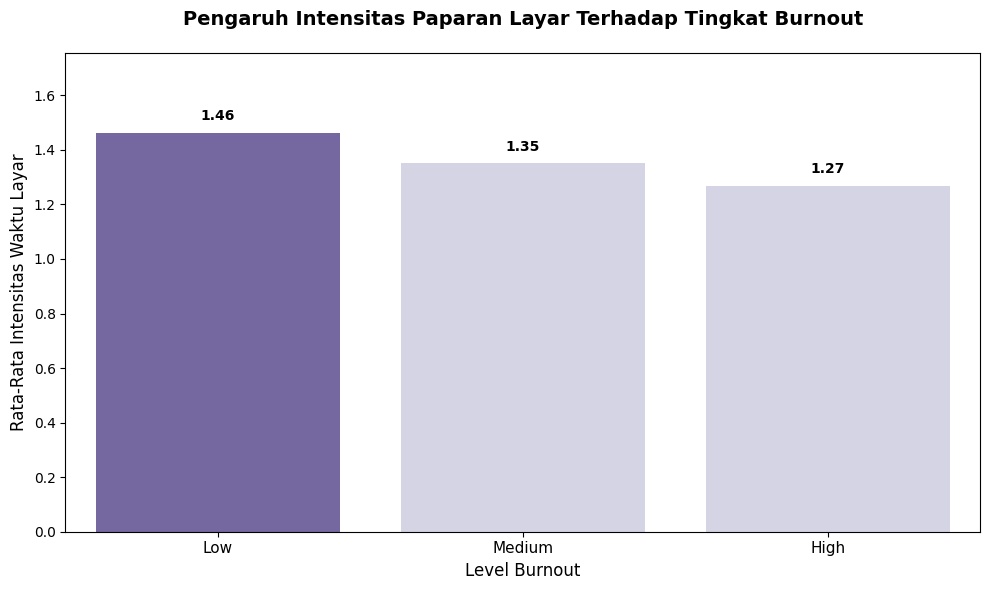

In [14]:
# Agregasi data untuk mencari nilai tertinggi
avg_intensity = df_clean.groupby('burnout_level', observed=False)['screen_time_intensity'].mean()
max_val = avg_intensity.max()

# Skema warna
palette_base = sns.color_palette("Purples", 6)
base_color = palette_base[1]
highlight_color = palette_base[4]

# List warna berdasarkan kondisi
colors = [highlight_color if i == avg_intensity.idxmax() else base_color for i in avg_intensity.index]

# Visualisasi
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=avg_intensity.index,
    y=avg_intensity.values,
    palette=colors,
    hue=avg_intensity.index,
    legend=False,
    errorbar=None
)
ax.set_xticks(range(len(avg_intensity.index)))
ax.set_xticklabels(['Low', 'Medium', 'High'], fontsize=11)
plt.ylim(0, max_val * 1.2)
plt.title('Pengaruh Intensitas Paparan Layar Terhadap Tingkat Burnout', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Level Burnout', fontsize=12)
plt.ylabel('Rata-Rata Intensitas Waktu Layar', fontsize=12)

# Label angka di atas bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 12),
                textcoords = 'offset points',
                fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:**
- Developer dengan burnout Low memiliki rata-rata intensitas waktu layar paling tinggi (1,46) dibandingkan kategori lainnya.
- Developer dengan burnout High menunjukkan rata-rata intensitas paling rendah (1,27).
- Penurunan angka intensitas pada tingkat burnout High menandakan bahwa kenaikan total jam kerja harian meningkat jauh lebih pesat daripada durasi penggunaan layar.
- Hasil ini mengindikasikan bahwa beban jam kerja secara keseluruhan merupakan faktor pendorong burnout yang lebih kuat dibandingkan rasio penggunaan layar terhadap jam kerja.

### **Pertanyaan Bisnis 5: Bagaimana hubungan antara efisiensi kerja dengan tingkat burnout developer? Apakah developer dengan efisiensi rendah cenderung mengalami burnout lebih tinggi?**

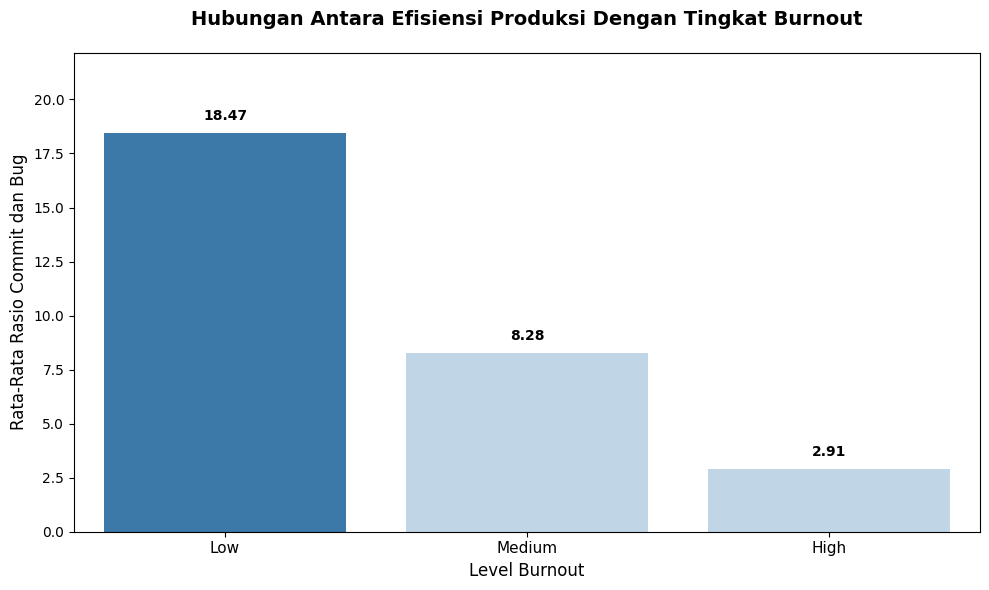

In [15]:
# Agregasi data untuk mencari nilai tertinggi
avg_efficiency = df_clean.groupby('burnout_level')['commit_bug_ratio'].mean()
max_val = avg_efficiency.max()

# Skema warna
palette_base = sns.color_palette("Blues", 6)
base_color = palette_base[1]
highlight_color = palette_base[4]

# List warna berdasarkan kondisi
colors = [highlight_color if i == avg_efficiency.idxmax() else base_color for i in avg_efficiency.index]

# Visualisasi
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=avg_efficiency.index,
    y=avg_efficiency.values,
    palette=colors,
    hue=avg_efficiency.index,
    legend=False,
    errorbar=None
)
ax.set_xticks(range(len(avg_efficiency.index)))
ax.set_xticklabels(['Low', 'Medium', 'High'], fontsize=11)
plt.ylim(0, max_val * 1.2)
plt.title('Hubungan Antara Efisiensi Produksi Dengan Tingkat Burnout', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Level Burnout', fontsize=12)
plt.ylabel('Rata-Rata Rasio Commit dan Bug', fontsize=12)

# Label angka di atas bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 12),
                textcoords = 'offset points',
                fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:**
- Developer dengan tingkat burnout Low memiliki rata-rata rasio commit terhadap bug paling tinggi yaitu sebesar 18,47.
- Developer dengan tingkat burnout High mencatatkan skor efisiensi paling rendah yaitu hanya sebesar 2,91.
- Terjadi penurunan efisiensi kerja yang sangat signifikan dan konsisten seiring dengan meningkatnya level burnout dari Low ke High.
- Data ini menunjukkan bahwa rendahnya efisiensi kerja yang diukur melalui rasio commit dan bug berkorelasi kuat dengan tingginya tingkat burnout pada developer.

## **Conclusion Analysis**

- **Conclusion Pertanyaan 1:** Berdasarkan hasil analisis, faktor jam kerja, waktu tidur, dan intensitas penggunaan layar memiliki pengaruh yang jelas terhadap tingkat burnout developer. Burnout yang lebih tinggi cenderung terjadi pada developer dengan jam kerja dan waktu layar yang tinggi, serta waktu tidur yang lebih rendah. Sebaliknya, developer dengan jam kerja lebih seimbang, waktu layar lebih rendah, dan waktu tidur yang cukup menunjukkan tingkat burnout yang lebih rendah. Dengan demikian, kombinasi beban kerja berlebih dan kurangnya waktu istirahat menjadi faktor utama yang meningkatkan resiko burnout.

---

- **Conclusion Pertanyaan 2:** Hasil analisis menunjukkan bahwa keseimbangan antara jam kerja dan waktu tidur memiliki pengaruh yang signifikan terhadap tingkat burnout developer. Semakin tidak seimbang rasio kerja terhadap istirahat, semakin tinggi tingkat burnout yang dialami. Developer dengan kondisi kerja yang jauh lebih dominan dibanding waktu istirahat cenderung mengalami burnout yang lebih tinggi, sedangkan keseimbangan antara kerja dan tidur terbukti mampu menekan resiko burnout. Dengan demikian, menjaga proporsi waktu kerja dan istirahat yang seimbang menjadi faktor penting dalam mengurangi burnout.

---

- **Conclusion Pertanyaan 3:** Berdasarkan hasil analisis, tingkat stres memiliki pengaruh yang sangat kuat terhadap tingkat burnout pada developer. Semakin tinggi tingkat stres yang dialami, semakin tinggi pula tingkat burnout yang terjadi. Pola peningkatan yang konsisten dari kategori rendah ke tinggi menunjukkan bahwa stres merupakan faktor utama yang mendorong terjadinya burnout. Oleh karena itu, pengelolaan stres menjadi aspek penting yang perlu diperhatikan untuk mengurangi resiko burnout pada developer.

---

- **Conclusion Pertanyaan 4:** Berdasarkan hasil analisis, intensitas paparan layar relatif terhadap jam kerja bukan merupakan pendorong utama burnout yang lebih berat. Developer dengan tingkat burnout tinggi memiliki nilai intensitas yang lebih rendah dikarenakan peningkatan total jam kerja harian yang jauh lebih dominan dibandingkan durasi penggunaan layar itu sendiri. Hal ini menunjukkan bahwa volume beban kerja secara keseluruhan memiliki pengaruh yang lebih signifikan terhadap resiko burnout dibandingkan dengan sekadar rasio intensitas waktu layar.

---

- **Conclusion Pertanyaan 5:** Hasil analisis menunjukkan bahwa efisiensi kerja memiliki hubungan yang sangat erat dan berbanding terbalik dengan tingkat burnout developer. Penurunan rasio commit terhadap bug yang konsisten dari level rendah ke tinggi membuktikan bahwa tingkat burnout yang berat berdampak langsung pada penurunan kualitas serta produktivitas hasil kerja. Dengan demikian, developer dengan efisiensi produksi yang rendah terbukti memiliki resiko burnout yang lebih tinggi, menjadikan skor efisiensi sebagai indikator yang kuat untuk memantau kondisi kesehatan mental kerja developer.

## **A/B Testing**

=== Ringkasan Data A/B Testing ===
Group A (Jam Kerja > 8 Jam)  : 411 konversi dari 4240 developer (0.0969)
Group B (Jam Kerja <= 8 Jam) : 1182 konversi dari 2760 developer (0.4283)

=== Hasil Uji Z-test Proporsi ===
Z-statistik: -32.3115
P-value    : 0.0000



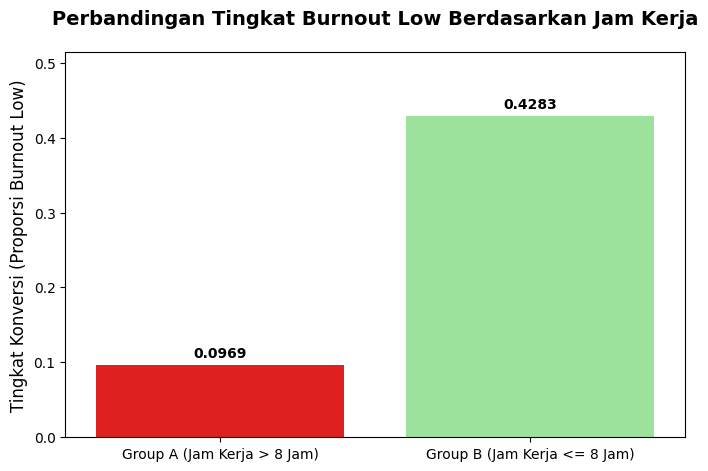

In [16]:
# Menyiapkan group berdasarkan metrik jam kerja harian
group_a = df_clean[df_clean['daily_work_hours'] > 8.0]
group_b = df_clean[df_clean['daily_work_hours'] <= 8.0]

n_obs_A = len(group_a)
n_obs_B = len(group_b)

# Menentukan konversi dengan keberhasilan adalah burnout low
success_A = len(group_a[group_a['burnout_level'] == 0])
success_B = len(group_b[group_b['burnout_level'] == 0])

conversion_rate_A = success_A / n_obs_A if n_obs_A > 0 else 0
conversion_rate_B = success_B / n_obs_B if n_obs_B > 0 else 0

print("=== Ringkasan Data A/B Testing ===")
print(f"Group A (Jam Kerja > 8 Jam)  : {success_A} konversi dari {n_obs_A} developer ({conversion_rate_A:.4f})")
print(f"Group B (Jam Kerja <= 8 Jam) : {success_B} konversi dari {n_obs_B} developer ({conversion_rate_B:.4f})")

# Uji z-test proporsi
z_stat, p_value = proportions_ztest(
    count=[success_A, success_B],
    nobs=[n_obs_A, n_obs_B],
    alternative='two-sided'
)

print("\n=== Hasil Uji Z-test Proporsi ===")
print(f"Z-statistik: {z_stat:.4f}")
print(f"P-value    : {p_value:.4f}\n")

# Visualisasi
labels = ['Group A (Jam Kerja > 8 Jam)', 'Group B (Jam Kerja <= 8 Jam)']
conversion_rates = [conversion_rate_A, conversion_rate_B]

plt.figure(figsize=(8, 5))
sns.barplot(
    x=labels,
    y=conversion_rates,
    hue=labels,
    palette=['red', 'lightgreen'],
    legend=False,
)
plt.title('Perbandingan Tingkat Burnout Low Berdasarkan Jam Kerja', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Tingkat Konversi (Proporsi Burnout Low)', fontsize=12)
plt.ylim(0, max(conversion_rates) * 1.2)

# Label angka di atas bar
for index, value in enumerate(conversion_rates):
    plt.text(index, value + 0.01, f'{value:.4f}', ha='center', fontweight='bold')

plt.show()

**Insight:**
- Berdasarkan uji statistik Z-test untuk proporsi, diperoleh nilai P-value (0,0000) yang jauh lebih kecil dari tingkat signifikansi 0,05, sehingga memberikan bukti statistik yang mutlak untuk menolak hipotesis nol (H0). Terdapat perbedaan konversi tingkat burnout Low yang sangat signifikan yaitu developer yang bekerja maksimal 8 jam sehari (Group B) memiliki tingkat konversi sebesar 42,83%, jauh melampaui developer yang bekerja lebih dari 8 jam (Group A) yang hanya mencapai 9,69%. Ini membuktikan bahwa peluang seorang developer untuk terhindar dari burnout meningkat lebih dari 4 kali lipat ketika jam kerja dijaga pada batas ideal.

## **Export Dataset**

In [17]:
df_clean.to_csv("burnout_main_data.csv", index=False)

**Insight:**
- Dataset yang sudah clean berhasil diekspor ke dalam file CSV.